In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import pygam as gm
import copy as cp

In [3]:
mydf = pd.read_pickle('data/Burgäschisee/dataset_Burgäschisee.pkl')
mydf = mydf.fillna(0)
mydf.index = -mydf.index
mydf = mydf.sort_index()

myspecies = list(mydf.columns[4:])

for spec in myspecies[:]: # ITERATE OVER A COPY
    if mydf[spec].sum() == 0:
        print('Species %s has all zeros!' %(spec))
        myspecies.remove(spec)
        mydf = mydf.drop(columns=[spec])

multipliers = mydf['Lycopodium added'] * mydf['acc_rate (mm/yr)'] / (mydf['volume (cm^3)'] * mydf['Lycopodium count'])
multipliers.name = 'multipliers'

mydf = mydf[myspecies]
mydf

Species Ranunculus has all zeros!
Species Castanea has all zeros!
Species Quercus caducifolio has all zeros!
Species Rhamnus has all zeros!
Species Polygonaceae has all zeros!
Species Cerealia type has all zeros!
Species Fagus has all zeros!
Species Juglans has all zeros!
Species Pinus has all zeros!
Species Fraxinus has all zeros!
Species Carpinus has all zeros!
Species Alnus has all zeros!
Species Corylus has all zeros!
Species Taxus has all zeros!
Species Juniperus has all zeros!
Species Buxus has all zeros!
Species Apiaceae has all zeros!
Species Ranunculaceae has all zeros!
Species Liliaceae has all zeros!
Species Saxifragaceae has all zeros!
Species Sambucus has all zeros!
Species Sanguisorba has all zeros!
Species Ephedra distachya has all zeros!
Species Ephedra fragilis has all zeros!
Species Ericaceae has all zeros!
Species Hereda helix has all zeros!
Species Lonicera has all zeros!
Species Olea has all zeros!
Species Asteroideae has all zeros!
Species Centaurea has all zeros!

name,Betula,Poaceae,Cannabis sativa,Ulmus,Picea abies,Pteridophyta (monolete),Salix,Tilia,Populus,Artemisia,...,Podospora-type,Abies,Platanus,Tussilago farfara,Larix decidua,Rhynchospora,Rosa,Helianthemum,Ilex aquifolium,Pistacia
age,,,,,,,,,,,,,,,,,,,,,
-6534.0,8.0,6.0,0.0,36.0,1.0,4.0,0.0,6.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-6522.0,7.0,9.0,0.0,37.0,2.0,4.0,2.0,11.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-6510.0,7.0,7.0,0.0,42.0,0.0,3.0,3.0,19.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-6497.0,11.0,4.0,0.0,41.0,0.0,3.0,0.0,10.0,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-6482.0,7.0,7.0,0.0,33.0,1.0,4.0,0.0,11.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26.0,27.0,109.0,8.0,7.0,41.0,10.0,9.0,2.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32.0,30.0,74.0,2.0,9.0,31.0,2.0,19.0,3.0,8.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38.0,35.0,81.0,2.0,7.0,60.0,5.0,16.0,3.0,3.0,2.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# GAM
fit_type = 'fit_723_0.01'
database = 'Burgäschisee'

n = 723
species = {}
vx = gm.utils.make_2d(mydf.index, verbose=False).astype('float')
for spec in myspecies:
    print('\tIterating on species %s ...' %(spec))
    vy = mydf[spec]

    mygam = gm.GAM(terms='auto', n_splines=n, lam=0.01).fit(vx, vy)
    # mygam = gm.GAM(terms='auto').gridsearch(vx, vy)

    species[spec] = {}
    species[spec]['prev_x'] = mydf.index.to_numpy()
    species[spec]['prev_y'] = mydf[spec].to_numpy()

    XX = mygam.generate_X_grid(term=0, n=n)
    YY = mygam.predict(XX)
    species[spec]['x'] = cp.copy(XX)[:,0]
    species[spec]['y'] = cp.copy(YY)

species_df = pd.DataFrame(species)
species_df.to_pickle(f'GAM_species/{database}/species_%s.pkl' %(fit_type))

species_index = {}
for i, spec in enumerate(myspecies):
    species_index[spec] = i
pd.to_pickle(species_index, f'./GAM_species/{database}/species_index.pkl')

	Iterating on species Betula ...
	Iterating on species Poaceae ...
	Iterating on species Cannabis sativa ...
	Iterating on species Ulmus ...
	Iterating on species Picea abies ...
	Iterating on species Pteridophyta (monolete) ...
	Iterating on species Salix ...
	Iterating on species Tilia ...
	Iterating on species Populus ...
	Iterating on species Artemisia ...
	Iterating on species Pteridium aquilinum ...
	Iterating on species Humulus lupulus ...
	Iterating on species Acer ...
	Iterating on species Brassicaceae ...
	Iterating on species Cichorioideae ...
	Iterating on species Amaranthaceae ...
	Iterating on species Sporormiella-type ...
	Iterating on species Hypericum ...
	Iterating on species Cercophora-type ...
	Iterating on species Dryopteris filix-mas ...
	Iterating on species Thelypteris palustris ...
	Iterating on species Rubiaceae ...
	Iterating on species Sordaria-type ...
	Iterating on species Athyrium filix-femina ...
	Iterating on species Typha latifolia ...
	Iterating on sp

OSError: Cannot save file into a non-existent directory: 'GAM_species/Burgäschisee'

In [ ]:
# GAM over multipliers
n_splines = n
fit_type = f'fit_{n_splines}_0.01'
vx = gm.utils.make_2d(multipliers.index, verbose=False).astype('float')
vy = multipliers.values

gam_multipliers = gm.GAM(terms='auto', n_splines=n_splines, lam=0.01).fit(vx, vy)

XX = gam_multipliers.generate_X_grid(term=0, n=n_splines)
YY = gam_multipliers.predict(XX)

gam_multipliers_df = pd.DataFrame({
    'cal BP': XX[:, 0],
    'multipliers': YY
})

gam_multipliers_df.to_pickle(f'./GAM_species/{database}/gam_multipliers_%s.pkl' %(fit_type))

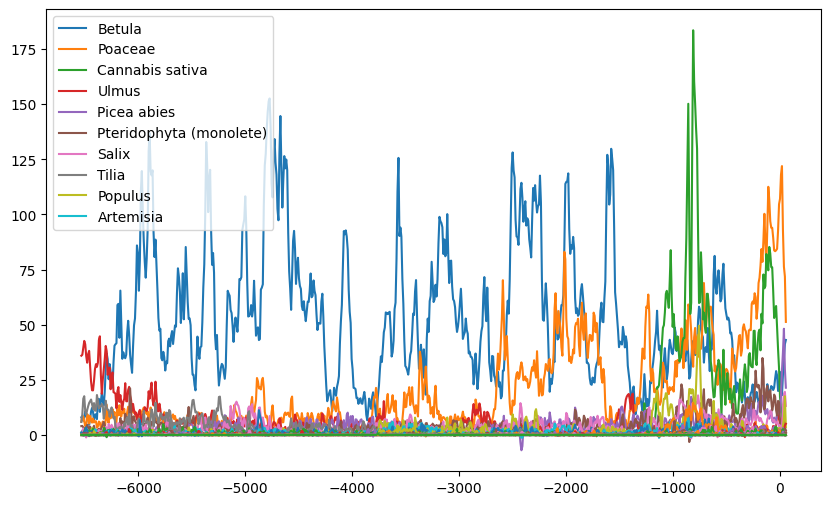

In [9]:
fig,ax = plt.subplots(figsize=(10, 6))
for spec in myspecies:
    ax.plot(species[spec]['x'], species[spec]['y'], label=spec)
# show the legend only for the first 10 species

handles, labels = ax.get_legend_handles_labels()

# 3. Slice them to only show the first 3 lines in the legend
ax.legend(handles[:10], labels[:10], loc='upper left')

<Axes: xlabel='cal BP'>

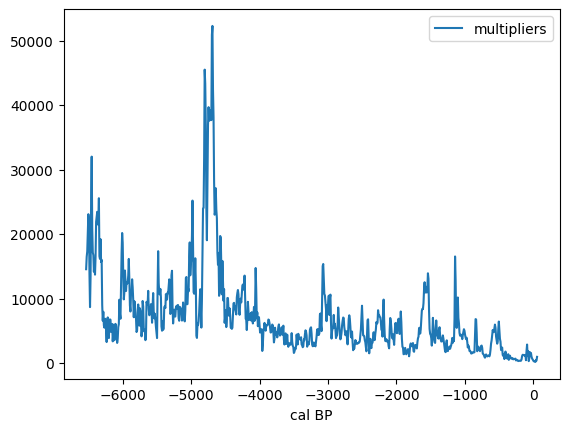

In [10]:
gam_multipliers_df.plot(x='cal BP', y='multipliers')

In [11]:
# GET TIME WINDOW CUTS

cuts = [-4900, -2300]

indices = species_df[myspecies[0]]['x'].searchsorted(cuts)
indices

array([180, 464])

In [16]:
import pandas as pd

In [21]:
np.array([[0,1,2],[3,4,5]]).sum(axis=0)

array([3, 5, 7])

In [20]:
x = np.array([0,1,2,3,4])
y = np.array([5,6,7,8,9])
z = np.array([[10,11,12,13,14],
              [15,16,17,18,19]])
data = pd.DataFrame(pd.DataFrame({'X': x, 'Y': y}))
# add the z array as columns (witih no name)
data = pd.concat([data, pd.DataFrame(z.T)], axis=1)
data

,X,Y,0,1
0,0,5,10,15
1,1,6,11,16
2,2,7,12,17
3,3,8,13,18
4,4,9,14,19
